Accuracy: 0.96

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       266
           1       0.96      0.96      0.96       311

    accuracy                           0.96       577
   macro avg       0.96      0.96      0.96       577
weighted avg       0.96      0.96      0.96       577



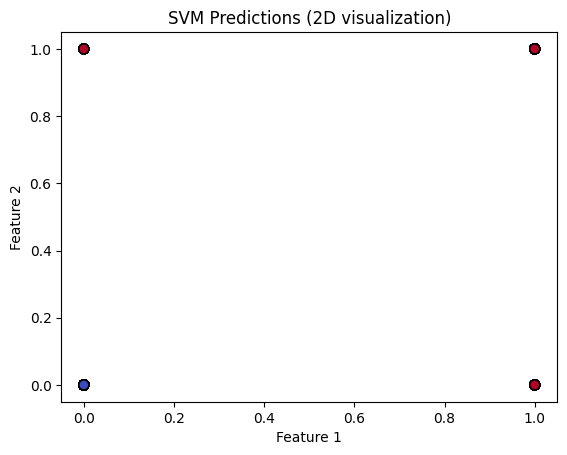

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Load a sample dataset (your dataset)
file_path = r"H:\Master Files\cleaned_data.xlsx"

# Read the Excel file
df = pd.read_excel(file_path, engine="openpyxl")

# Features and target
df_cleaned = df.drop(columns=["CASE_NO_PATIENT'S"], errors='ignore')

# Step 3: Encode categorical variables
from sklearn.preprocessing import LabelEncoder
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le  # Store for later use

# Step 4: Feature Selection
X = df_cleaned.drop(columns=["ASD_traits"], errors='ignore')  # Features (Ensure the column name is correct here)
y = df_cleaned["ASD_traits"]  # Target (Ensure the column name is correct here)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the SVM classifier with a linear kernel
svm_model = SVC(kernel='linear')

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# Visualize the results (for 2D)
# Let's just plot the first two features for simplicity (use .iloc for indexing)
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_pred, cmap=plt.cm.coolwarm, marker='o', edgecolors='k', s=50)
plt.title("SVM Predictions (2D visualization)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [2]:
# Import necessary metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Calculate Precision
precision = precision_score(y_test, y_pred, average='weighted')  # 'weighted' handles imbalanced classes
print(f'Precision: {precision:.2f}')

# Calculate Recall
recall = recall_score(y_test, y_pred, average='weighted')  # 'weighted' handles imbalanced classes
print(f'Recall: {recall:.2f}')

# Calculate F1 Score
f1 = f1_score(y_test, y_pred, average='weighted')  # 'weighted' handles imbalanced classes
print(f'F1 Score: {f1:.2f}')

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error (MSE): {mse:.2f}')

Accuracy: 0.96
Precision: 0.96
Recall: 0.96
F1 Score: 0.96
Mean Squared Error (MSE): 0.04


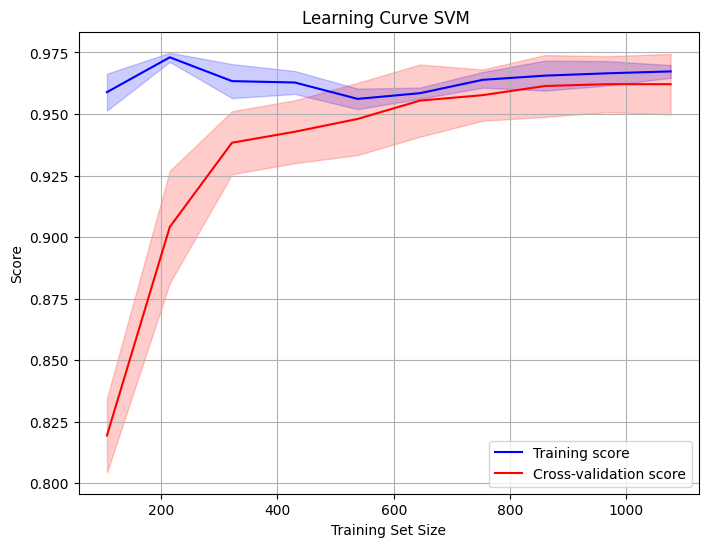

In [3]:
# Import necessary libraries for learning curve
from sklearn.model_selection import learning_curve

# Compute the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=svm_model, 
    X=X_train, 
    y=y_train, 
    train_sizes=np.linspace(0.1, 1.0, 10),  # Vary training set size from 10% to 100%
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Measure accuracy
    n_jobs=-1  # Use all available cores
)

# Calculate the mean and standard deviation of training and testing scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Training score", color='blue')
plt.plot(train_sizes, test_mean, label="Cross-validation score", color='red')

# Fill between the training and testing score for the standard deviation
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='red', alpha=0.2)

# Set plot labels and title
plt.title("Learning Curve SVM ")
plt.xlabel("Training Set Size")
plt.ylabel("Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

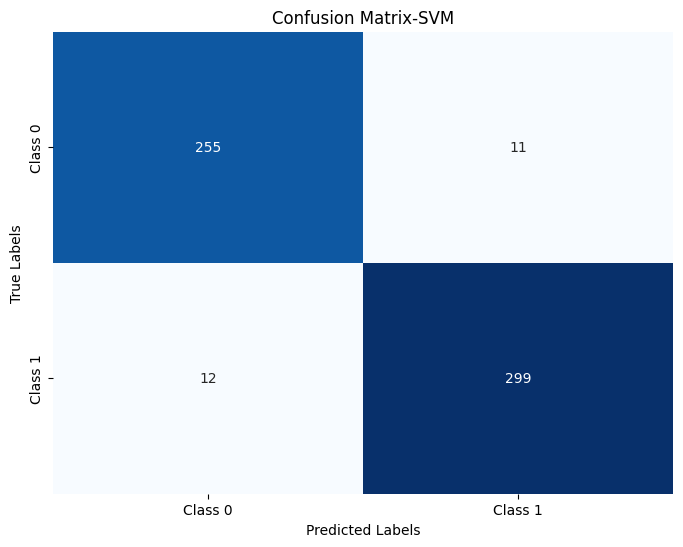

In [4]:
# Import the confusion_matrix function
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using Seaborn's heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title("Confusion Matrix-SVM")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

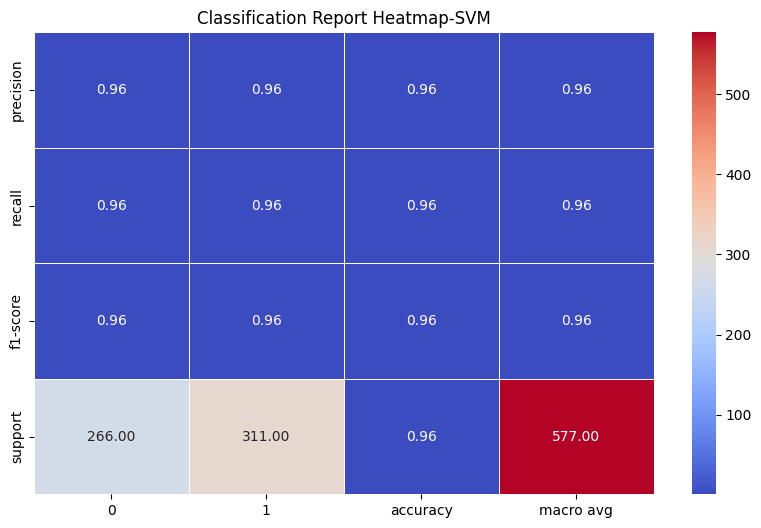

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import pandas as pd

# Generate the classification report as a dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# Convert the dictionary to a DataFrame
report_df = pd.DataFrame(report).T

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :].T, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Classification Report Heatmap-SVM')
plt.show()

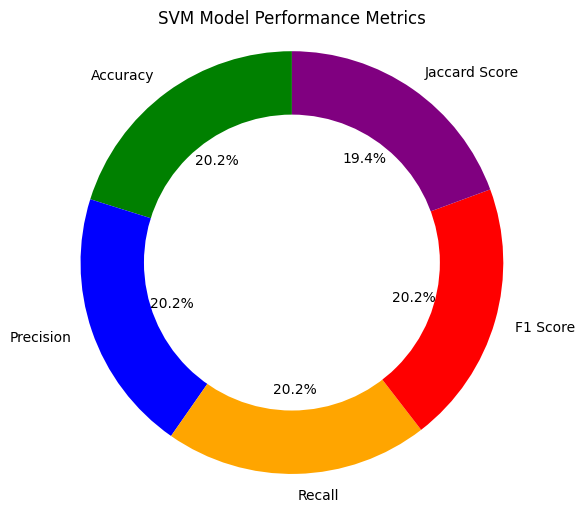

In [6]:
# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score, mean_squared_error

# 🔹 Compute Performance Metrics for your model (for example, SVM model in this case)
accuracy_svm = accuracy_score(y_test, y_pred)
precision_svm = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall_svm = recall_score(y_test, y_pred, average='weighted')
f1_svm = f1_score(y_test, y_pred, average='weighted')
jaccard_svm = jaccard_score(y_test, y_pred, average='macro')
mse_svm = mean_squared_error(y_test, y_pred)

# 🔹 Function to Plot Donut Chart for Model Performance Metrics
def plot_svm_metrics_donut(accuracy, precision, recall, f1, jaccard):
    metrics = [accuracy, precision, recall, f1, jaccard]
    labels = ["Accuracy", "Precision", "Recall", "F1 Score", "Jaccard Score"]
    colors = ['green', 'blue', 'orange', 'red', 'purple']

    plt.figure(figsize=(6, 6))
    plt.pie(metrics, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)

    # Draw a circle in the center to create a donut chart
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.axis('equal')  # Keep it circular
    plt.title("SVM Model Performance Metrics")
    plt.show()

# 🔹 Plot the Donut Chart for SVM Model
plot_svm_metrics_donut(accuracy_svm, precision_svm, recall_svm, f1_svm, jaccard_svm)

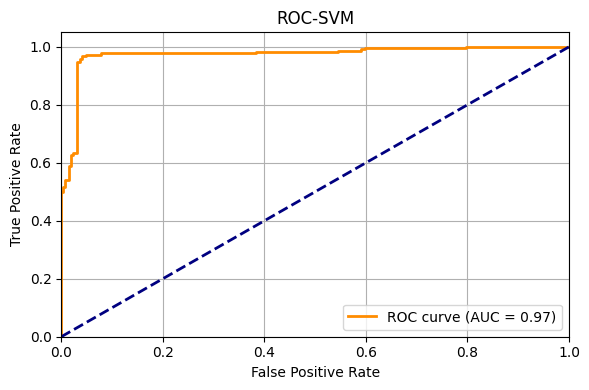

In [7]:
from sklearn.metrics import roc_curve, auc

# Check if binary classification
if len(np.unique(y)) == 2:
    y_prob = svm_model.decision_function(X_test)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-SVM')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


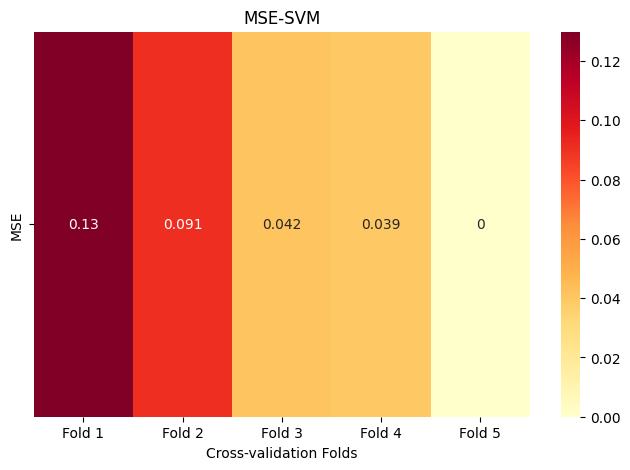

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset (replace this with your actual dataset)
file_path = r"H:\Master Files\cleaned_data.xlsx"
df = pd.read_excel(file_path, engine="openpyxl")

# Drop irrelevant columns and preprocess
df_cleaned = df.drop(columns=["CASE_NO_PATIENT'S"], errors='ignore')

# Encode categorical variables
label_encoders = {}
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le

# Feature selection (assuming 'ASD_traits' is the target)
X = df_cleaned.drop(columns=["ASD_traits"], errors='ignore')  # Features
y = df_cleaned["ASD_traits"]  # Target

# Initialize the SVM classifier with a linear kernel
svm_model = SVC(kernel='linear', probability=True)

# Create a custom scoring function for MSE
mse_scorer = make_scorer(mean_squared_error)

# Perform cross-validation to get MSE values
cv_scores = cross_val_score(svm_model, X, y, cv=5, scoring=mse_scorer)

# Visualization of MSE in a Single Rectangle
plt.figure(figsize=(8, 5))
sns.heatmap(cv_scores.reshape(1, -1), annot=True, cmap='YlOrRd', cbar=True, 
            xticklabels=[f'Fold {i+1}' for i in range(len(cv_scores))], 
            yticklabels=["MSE"])
plt.title('MSE-SVM')
plt.xlabel('Cross-validation Folds')
# plt.ylabel('MSE')
plt.show()

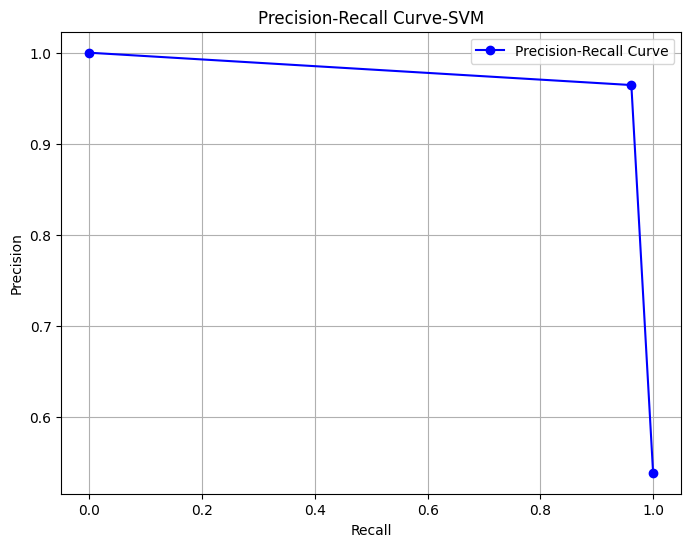

✅ Average Precision Score: 0.9481


In [11]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='o', linestyle='-', color='b', label="Precision-Recall Curve")
plt.title("Precision-Recall Curve-SVM")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend()
plt.show()

# Calculate Average Precision Score (Optional)
avg_precision = average_precision_score(y_test, y_pred)
print(f"✅ Average Precision Score: {avg_precision:.4f}")


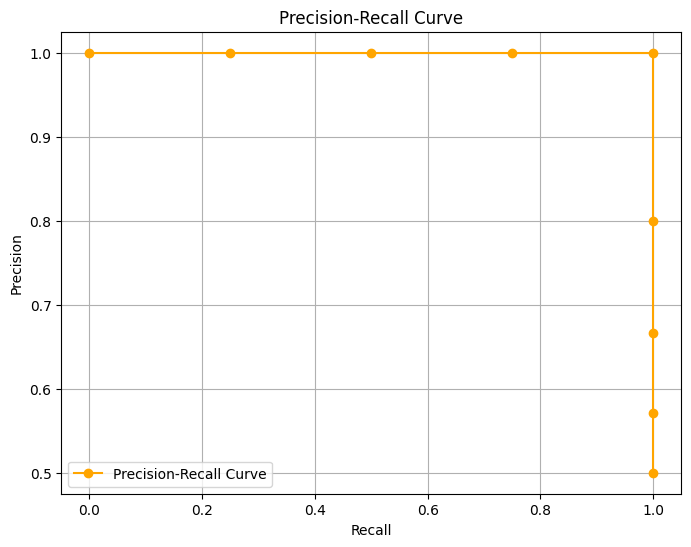

✅ Average Precision Score: 1.0000


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Assuming y_test and y_pred are already defined
# Example data for y_test and y_pred (replace with your actual data)
y_test = [0, 1, 1, 0, 1, 0, 1, 0]  # True labels
y_pred = [0.1, 0.9, 0.8, 0.2, 0.7, 0.3, 0.6, 0.4]  # Predicted probabilities

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# Plot Precision-Recall curve with colored line
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='o', linestyle='-', color='orange', label="Precision-Recall Curve")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend()
plt.show()

# Calculate Average Precision Score
avg_precision = average_precision_score(y_test, y_pred)
print(f"✅ Average Precision Score: {avg_precision:.4f}")
